## Pip install ydata-profiling

In [327]:
!pip install ydata-profiling
!pip install umap-learn


# Import Libraries

In [329]:
import umap
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import drive
import matplotlib.pyplot as plt
from keras.datasets import mnist
from ydata_profiling import ProfileReport

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


## Read Dataset

In [225]:
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datasets/bankloan.csv")
df.head(5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Row ID,id,member_id,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,...,application_type,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,Unnamed: 50,36months,60months
0,1.0,60516983,64537751,20000,20000,36 months,12.29,667.06,C,C1,...,INDIVIDUAL,NaN,NaN,0,0,52303,41000,NaN,1.0,0.0
1,2.0,60187139,64163931,11000,11000,36 months,12.69,369.00,C,C2,...,INDIVIDUAL,NaN,NaN,0,332,175731,13100,NaN,1.0,0.0
2,3.0,60356453,64333218,7000,7000,36 months,9.99,225.84,B,B3,...,INDIVIDUAL,NaN,NaN,0,0,202012,16300,NaN,1.0,0.0
3,4.0,59955769,63900496,10000,10000,36 months,10.99,327.34,B,B4,...,INDIVIDUAL,NaN,NaN,0,0,108235,34750,NaN,1.0,0.0
4,5.0,58703693,62544456,9550,9550,36 months,19.99,354.87,E,E4,...,INDIVIDUAL,NaN,NaN,0,0,45492,14100,NaN,1.0,0.0


## Question 1
Describe dataset features

### Answer
*My computer was lagging with this ydata-profiling and so I donwload the html and read it into my browser.*


**After a thorough check of the data, the following characteristics are observed:**

Loans:
- We have no Nan values ​​and it is unbalanced
- The amount applied for by the borrower is the same as approved by the LC

More than 60% of the dataset has paid in 36 months instead of 60

Loan interest rates are relatively low with the highest values ​​between 6-15

The monthly payment due by the borrower is basically below 500 and above 100

Grade: More cases where we have Grade B, C, A and much less in the other categories, meaning the dataset has more candidates to be approved

emp_title: It is observed that most of those who apply are:
- Manager
- director
- supervisor
- engineer
- Sales
- assistant

Most of those who want a loan either have over from 10 years of experience or less than a year (the majority of all others are in much smaller percentages)

The situation of most of the people who have applied is with a spouse or have taken it out with a loan

Those who want a loan have a claimed income of 15029 (71.7%)

The incomes that are real have been verified by 72% while 28% have not

Most loans are given to the world on October 15th after November-December-August and July

Most loans are for debt consolidation and credit card refinancing

Most people seem to have not been late in paying their installments in the last two years (79.3% zero)

---
**These features are unbalanced:**

loan_status is highly imbalanced (90.0%)	Imbalance

purpose is highly imbalanced (50.9%)	Imbalance

title is highly imbalanced (52.3%)	Imbalance

last_pymnt_d is highly imbalanced (75.3%)	Imbalance

next_pymnt_d is highly imbalanced (66.7%)	Imbalance

last_credit_pull_d is highly imbalanced (97.2%)	Imbalance

application_type is highly imbalanced (97.9%)

---
**Many values have missing values but these values have huge gap:**

Row ID has 212631 (99.8%) missing values	Missing

mths_since_last_delinq has 103371 (48.5%) missing values	Missing

mths_since_last_major_derog has 150634 (70.7%) missing values	Missing

annual_inc_joint has 212558 (99.8%) missing values	Missing

dti_joint has 212560 (99.8%) missing values	Missing

Unnamed: 50 has 212999 (100.0%) missing values	Missing

36months has 212488 (99.8%) missing values	Missing

60months has 212488 (99.8%) missing values	Missing

*We observe that many values are completly missing which might lead to completly remove them.*

---
**These values have the highest correlation in the dataset:**

36months is highly overall correlated with 60months and 10 other fields

60months is highly overall correlated with 36months and 10 other fields

funded_amnt is highly overall correlated with 36months and 9 other fields

loan_amnt is highly overall correlated with 36months and 9 other fields

loan_status is highly overall correlated with 36months and 9 other fields

total_pymnt is highly overall correlated with funded_amnt and 8 other fields

total_rec_int is highly overall correlated with funded_amnt and 8 other fields

total_rec_prncp is highly overall correlated with funded_amnt and 7 other fields

*I only mentioned features with more than 7 correlations because there are enough high correlations in the dataset but it is more important to focus on features which has the most correlations*


---

**These values have large amount of zeros:**

delinq_2yrs has 168803 (79.3%) zeros	Zeros

inq_last_6mths has 130719 (61.4%) zeros	Zeros

pub_rec has 175316 (82.3%) zeros	Zeros

total_rec_late_fee has 212587 (99.8%) zeros	Zeros

recoveries has 212693 (99.9%) zeros	Zeros

collection_recovery_fee has 212698 (99.9%) zeros	Zeros

collections_12_mths_ex_med has 208798 (98.0%) zeros	Zeros

acc_now_delinq has 211858 (99.5%) zeros	Zeros

tot_coll_amt has 178893 (84.0%) zeros	Zeros

*As we can see there are 8 values which are high unbalanced with most of the values be zero. This features cannot help the training proccess*

## Question 2

1) What is the average, maximum, minimum loan_amnt amount requested by applicants in the dataset?
2) Which variables can we remove for training a model? Remove the variables that are not needed.
3) Apply any other preprocessing method you consider necessary.
4) Suppose the bank decides to grant loans to A, B1, B2 and as a target we consider whether a candidate will receive a loan or not (i.e. whether he will be in categories A, B1 or B2) what do you conclude about the targets? Create a corresponding column for the targets.
5) Is there a requested amount range (e.g. from 20000-25000) (loan_amnt) that will be accepted for a loan with a probability of at least 15% of those who apply for it? If Yes, find and report in an appropriate way such a range

### What is the average, maximum, minimum loan_amnt amount requested by applicants in the dataset?

Use functoin describe to get values for loan_amount only:

**Average:** Average is the mean value, which in this case is 15257.96

**Minimum:** Minimum is the min value, which in this case is 1000

**Maximum:** Maximum is the max value, which in this case is 35000


In [226]:
df['loan_amnt'].describe()

,loan_amnt
count,212999.000000
mean,15257.965530
std,8611.713377
min,1000.000000
25%,8500.000000
50%,14000.000000
75%,20000.000000
max,35000.000000


### Which variables can we remove for training a model? Remove the variables that are not needed

To do such a thing we are looking at Question 1 answer which provides information about important and not important features. I will mention five categories which I consider to remove the variables:

**Missing 100%:**
  - Row ID
  - annual_inc_joint
  - dti_joint
  - Unnamed: 50
  - 36months
  - 60months
  - mths_since_last_delinq
  - mths_since_last_major_derog

**Mostly zeros / uninformative:**
  - total_rec_late_fee
  - recoveries
  - collection_recovery_fee
  - collections_12_mths_ex_med
  - acc_now_delinq
  - tot_coll_amt
  - pub_rec
  - delinq_2yrs
  - inq_last_6mths

**Extremely imbalanced categorical**
  - application_type
  - last_credit_pull_d
  - last_pymnt_d
  - next_pymnt_d
  - title

**Leakage variables:**
  - total_pymnt
  - total_rec_int
  - total_rec_prncp
  - out_prncp
  - last_pymnt_amnt
  - loan_status

**Ids:**
  - id
  - member_id

**Redundant by correlation:**
  - funded_amnt


It is logical that to remove non informative values (Missing 100%, Mostly zeros).

Other than that also remove imbalanced categories which will lead the model to make false predictions and cannot generalize well.

Variables which are used after the bank give the loan are giving data leakage and so it is important to remove them.

Also it is important to remove ids since there are non-informative values

Last feature to remove is funded amount because it has high correlation with feature which has 99.8% missing values. (also remove 36months and 60months but we remove them in previous step)


*Remove also grade because it is redundant with sub_grade which creates multicollinearity. sub_grade provides too much details which satisfies completely grade feature*

In [227]:
# Not important columns to remove
columns_to_drop = ['grade', 'title', 'out_prncp', 'last_pymnt_amnt', 'loan_status', 'id', 'member_id',"Row ID","annual_inc_joint","dti_joint","Unnamed: 50","36months","60months","mths_since_last_delinq","mths_since_last_major_derog","total_rec_late_fee","recoveries","collection_recovery_fee","collections_12_mths_ex_med","acc_now_delinq","tot_coll_amt","pub_rec","delinq_2yrs","inq_last_6mths","application_type","last_credit_pull_d","last_pymnt_d","next_pymnt_d","total_pymnt","total_rec_int","total_rec_prncp","funded_amnt"]

print(f"Dataframe len before {len(df.columns)}")
df = df.drop(columns=columns_to_drop, axis=1)
print(f"Dataframe len after {len(df.columns)}")


Dataframe len before 53
Dataframe len after 21


### Apply any other preprocessing method you consider necessary.

- Fill nan values with Unkown (there are only 6% of the column). Only for emp_title and length
- Fill nan values in revol_util (82 missing values) with the median.
- Convert Categorical to numerical

In [217]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'purpose', 'dti', 'earliest_cr_line',
       'open_acc', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'tot_cur_bal', 'total_rev_hi_lim'],
      dtype='object')

In [230]:
# Fill with uknown
df['emp_title'] = df['emp_title'].fillna('Unknown')
df['emp_length'] = df['emp_length'].fillna('Unknown')

# Fill with median
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].mean())

# Ordinal Encoding (because one hot encoding will crete 35 different categories)
enc = OrdinalEncoder()
df['sub_grade'] = enc.fit_transform(df[['sub_grade']])

# Binary encoding for term
df['term'] = df['term'].map({' 36 months': 0, ' 60 months': 1})

# One hot encoding for small categorical features
df = pd.get_dummies(df, columns=['home_ownership', 'verification_status', 'purpose', 'initial_list_status'], drop_first=True)


# There are 69667 unique values for emp_title so drop is the safest decision
df = df.drop(columns=['emp_title'], axis=1)

# Corrupted columns (years are combined with months so there is no clear view of the values)
df = df.drop(columns=['earliest_cr_line'], axis=1)
df = df.drop(columns=['issue_d'], axis=1)

# Convert string years into float
df['emp_length'] = df['emp_length'].replace({"< 1 year":"0", "Unknown":"0"})
df['emp_length'] = df['emp_length'].str.extract(r'(\d+)').astype(float)

In [231]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212999 entries, 0 to 212998
Data columns (total 33 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            212999 non-null  int64  
 1   term                                 212999 non-null  int64  
 2   int_rate                             212999 non-null  float64
 3   installment                          212999 non-null  float64
 4   sub_grade                            212999 non-null  float64
 5   emp_length                           212999 non-null  float64
 6   annual_inc                           212999 non-null  float64
 7   dti                                  212999 non-null  float64
 8   open_acc                             212999 non-null  int64  
 9   revol_bal                            212999 non-null  int64  
 10  revol_util                           212999 non-null  float64
 11  total_acc    

### Suppose the bank decides to grant loans to A, B1, B2 and as a target we consider whether a candidate will receive a loan or not (i.e. whether he will be in categories A, B1 or B2) what do you conclude about the targets? Create a corresponding column for the targets.


Before and after creating the bar plots the dataset is clearly unbalanced. This will lead the model to predict most of the times zero (0) which means that the model will say most of the times that the bank should not grant feature loans.

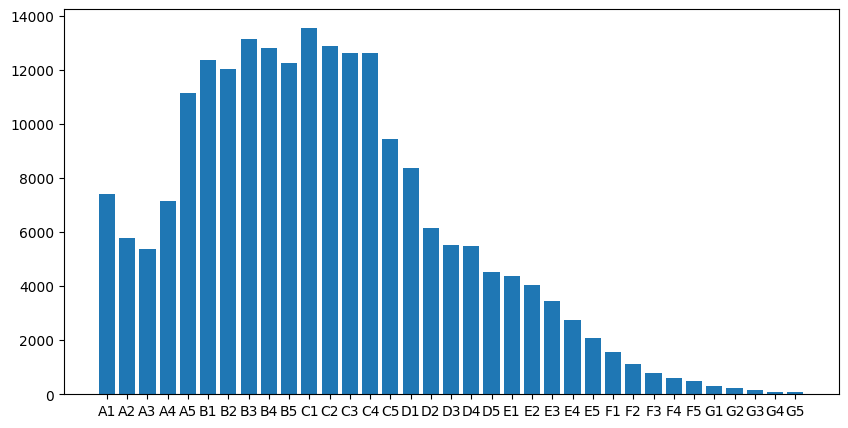

Counts of A, B1, B2:  61290
Count of all others:  151709


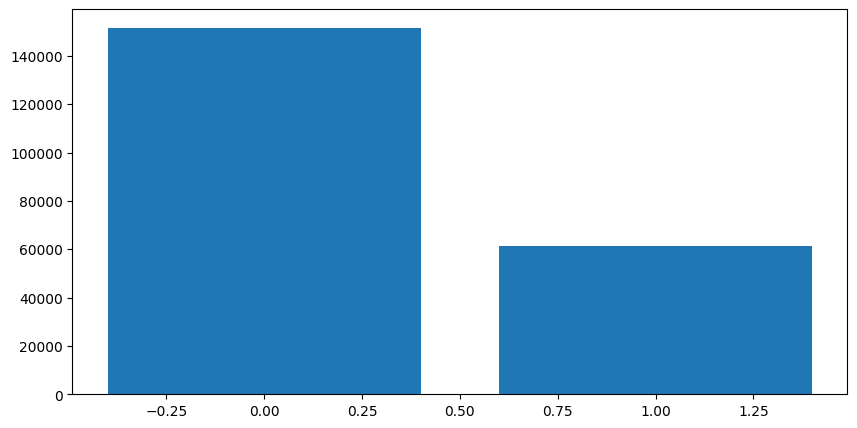

In [228]:
values , counts = np.unique(df["sub_grade"], return_counts = True)

plt.figure(figsize=(10,5))
plt.bar(values, counts)
plt.show()

count_list = ['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2']
all_count = 0
other_counts = 0
for i, c in enumerate(counts):
  if i < len(count_list):
    all_count += counts[i]
  else:
    other_counts += counts[i]

print("Counts of A, B1, B2: ", all_count)
print("Count of all others: ", other_counts)

df['target'] = df['sub_grade'].isin(count_list).astype(int)

values , counts = np.unique(df["target"], return_counts = True)
plt.figure(figsize=(10,5))
plt.bar(values, counts)
plt.show()


### Is there a requested amount range (e.g. from 20000-25000) (loan_amnt) that will be accepted for a loan with a probability of at least 15% of those who apply for it? If Yes, find and report in an appropriate way such a range

Yes there are more than one ranges which are acceptable for a loan with a probability of at least 15%. In the code below by changing loan amount variable we can get all the acceptable ranges. For this example I meantion some ranges from loan amount = 2000 and 5000.

[0, 2000] (0.15%)

[2000, 4000] (0.21%)

[26000, 28000] (0.38%)

[28000, 30000] (0.30%)

[30000, 32000] (0.17%)

[0, 5000] (0.25%)

[5000, 10000] (0.36%)

[10000, 15000] (0.31%)

[15000, 20000] (0.30%)

[20000, 25000] (0.30%)

[25000, 30000] (0.31%)


In [229]:
laon_amount = 5000
min = 0


for step in range(laon_amount, df['loan_amnt'].max()+1, laon_amount):

  # Brake dataset into the range
  df_step = df[(df['loan_amnt'] >= min) & (df['loan_amnt'] <= step)]

  # Get the percentage of target = 1 divided with the total df len
  percentage = len(df_step[df_step['target'] == 1])/len(df_step)

  # Show only acceptable ranges
  if percentage >= 0.15:
    print(f"[{min}, {step}] ({percentage:.2f}%)")

  # Go to the next range
  min = step


[0, 5000] (0.25%)
[5000, 10000] (0.36%)
[10000, 15000] (0.31%)
[15000, 20000] (0.30%)
[20000, 25000] (0.30%)
[25000, 30000] (0.31%)


## Use a Classifier to predict whether a candidate is good for lending (according to question 2.4). You should:
1. Normalize the inputs in an appropriate way. You are free to choose a method, but you should justify it.
2. Split the dataset appropriately into train, test sets in (70-30). Use the Stratify method for the separation.
3. Apply an appropriate classifier to predict the lending of a candidate. You can use any model you want, as long as you justify its choice. In addition, if you want, you can apply cross-validation on the train set to find appropriate parameters of your model. Since the dataset is large, choose only the most sensitive parameter (optional). WARNING: There is a variable that betrays the target, as the bank assigns both the category of the candidate and the value of this variable. Find this variable and remove it.
4. Report the accuracy, F1, Precision, Recall for the best model in the validation set. Which metrics are most important for this application? Justify

### Pipeline

- Split dataset with Stratified Train-Test split (70-30)
-  Use Standard Scaler for normilization
    - I use this method because it is stable for dataset with different ranges and also it is suitable for distance based regularization models
- Use scikit learn Pipeline to add standard scaler with the model (use Logistic Regression since it is fast, interpretable and works well with normilized data and also it is working well with big datasets)

*Subgrade is data leak and model will overfit*



In [253]:
# Create x, y
X = df.drop(['target', 'sub_grade'], axis = 1)
y = df['target']

# Apply train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Create the pipeline for LogisticRegression
pipeline_logistic_regression = Pipeline([
    ('scaler', StandardScaler()),
    ('classification_model', LogisticRegression(max_iter=2000))
])

# Train the models
pipeline_logistic_regression.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('classification_model', LogisticRegression(max_iter=2000))])

#### Classification Report
Model had perfect results in test set with 99% in every metric.

This means that the dataset classes can easily be separated.

**Answer in question which metric is the most important:**

Precision is the most safe metric since the bank want to know for sure which people are going to pay the loan and so there is no danger to accept loans in which people will not pay. It is more profitable for the company to reject people who will pay the loan than to accept those who will not pay it and will incur losses.

In [255]:
y_pred = pipeline_logistic_regression.predict(X_test)
rfc_y_pred = rfc.predict(X_test)

print("Linear Regression Test Accuracy:", accuracy_score(y_test, y_pred))
print("Linear Regression  Test Precision:", precision_score(y_test, y_pred))
print("Linear Regression Test Recall:", recall_score(y_test, y_pred))
print("Linear Regression Test F1:", f1_score(y_test, y_pred))



Linear Regression Test Accuracy: 0.9999217527386541
Linear Regression  Test Precision: 0.9997824904839586
Linear Regression Test Recall: 0.9999456137488443
Linear Regression Test F1: 0.9998640454631971


## Question 4 (Feature Importance & Selection):
1. Train a Random Forest classifier (provided you apply normalization and train/test split) and report the 15 most important features in loan prediction.
2. Print the correlation matrix for these features. Is there any correlation between these features?
3. Keep some features that have low correlation with each other and Repeat question 1.

In [256]:
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

rfc_y_pred = rfc.predict(X_test)
print("Random Forest Test Accuracy:", accuracy_score(y_test, rfc_y_pred))
print("Random Forest Test Precision:", precision_score(y_test, rfc_y_pred))
print("Random Forest Test Recall:", recall_score(y_test, rfc_y_pred))
print("Random Forest Test F1:", f1_score(y_test, rfc_y_pred))

Random Forest Test Accuracy: 0.9999374021909233
Random Forest Test Precision: 0.9997825023109129
Random Forest Test Recall: 1.0
Random Forest Test F1: 0.9998912393278591


### Plot results to have a view of feature importance
Model is mainly based on int_rate

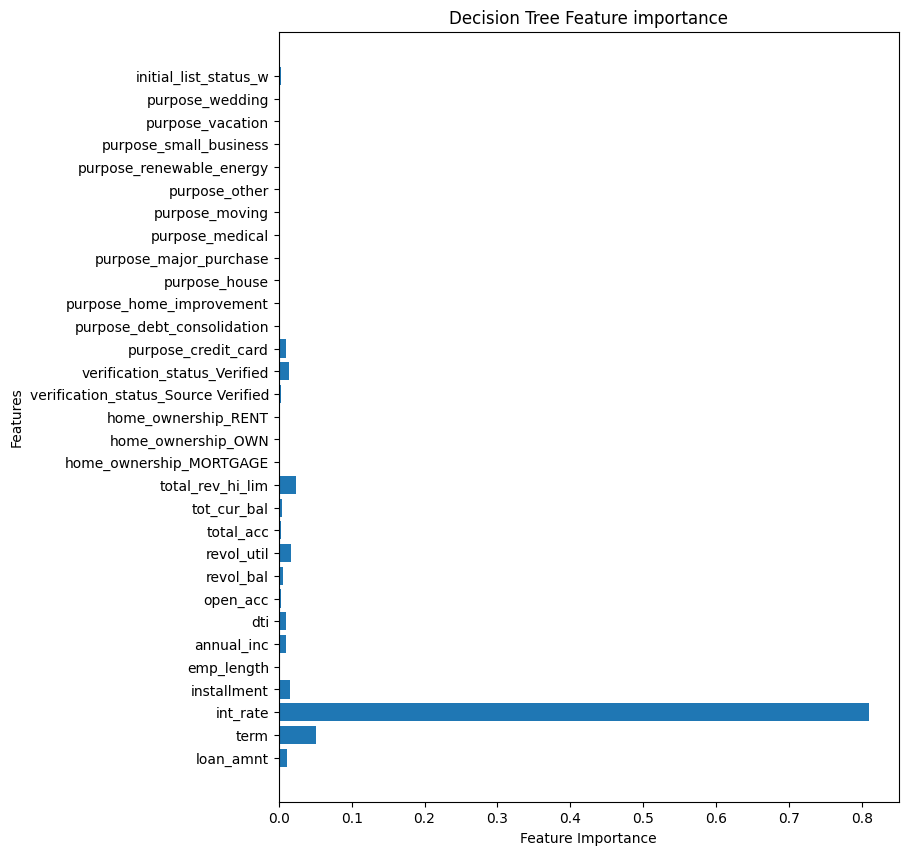

In [266]:
feature_names = df.drop(['target', 'sub_grade'], axis=1).columns
importance_weights = rfc.feature_importances_
plt.figure(figsize=(8, 10))
plt.barh(feature_names, importance_weights)
plt.title('Decision Tree Feature importance')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.show()

In [273]:
# Get only 15 feature importances

importances = pd.Series(importance_weights, index=feature_names)
top_15 = importances.sort_values(ascending=False).head(15) # Asceding to get the highest importand features

### Corelation matrix

**Obervations:**

revol_bal with total_rev_hi_lim (0.85)

small correlation with tot_cur_bal and total_rev_hi_lim(0.44)

moderate correlation of tot_cur_bar with revol_bar (0.46)

large correlation loan_amnt with installment(0.94)

moderate correlation of term with int_rate (0.45)

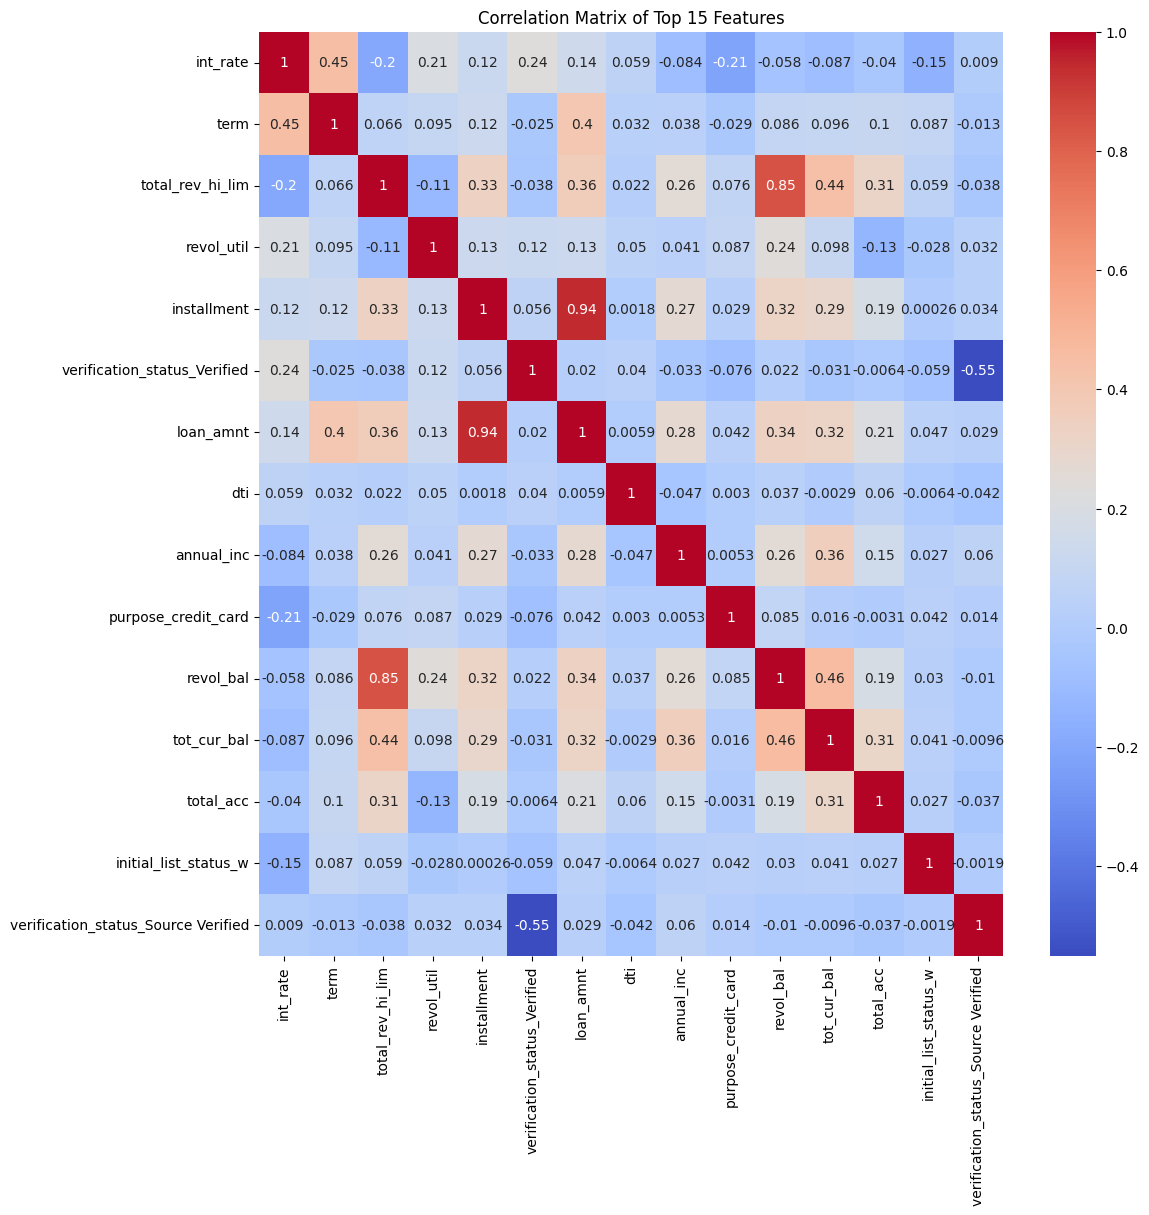

In [285]:
# Initialize correlation matrix
correlation_matrix = df[top_15.index].corr()

# Plot the heatmap
plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Top 15 Features")
plt.show()

### Keep some features that have low correlation with each other and Repeat question 1.



In [300]:
low_corr_features = []

for col in top15_features:
    if all(abs(corr_matrix[col][low_corr_features]) < 0.30): #Take the absolute value of every column we add them together and see if the correlation is more than 0.3 which is a low threshold
        low_corr_features.append(col)

print("Low correlation features:")
print(low_corr_features)

Low correlation features:
['int_rate', 'total_rev_hi_lim', 'revol_util', 'verification_status_Verified', 'dti', 'annual_inc', 'purpose_credit_card', 'initial_list_status_w']


### Train model with low correlation values

The reason why the results are still perfect is because the less correlated feature is int_rate which is the most important feature. Random Forest doesn't rely on feature independence and so int_rate can explains the 80-90% of the model's predictive power

In [302]:
# Create x, y
X = df[low_corr_features]
y = df['target']

# Apply train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

rfc_y_pred = rfc.predict(X_test)
print("Random Forest Test Accuracy:", accuracy_score(y_test, rfc_y_pred))
print("Random Forest Test Precision:", precision_score(y_test, rfc_y_pred))
print("Random Forest Test Recall:", recall_score(y_test, rfc_y_pred))
print("Random Forest Test F1:", f1_score(y_test, rfc_y_pred))

Random Forest Test Accuracy: 0.9999374021909233
Random Forest Test Precision: 0.9997825023109129
Random Forest Test Recall: 1.0
Random Forest Test F1: 0.9998912393278591


## Question 5
1. Load the MNIST black-and-white digit dataset.
2. Apply the Standard Scaling method to the data.
3. Apply PCA to reduce the features to 300. Then, train a KNN classifier with k=5,15,51, 101. Note: We want to call pca.fit_transform for the train set, but only the pca.transform function for the test set. Justify what would happen if we applied the fit transform to x_train and x_test separately, or to all of them together (i.e. if we joined x_train, x_test and applied pca) and calculate the accuracy of the classifier for each k.
4. Apply LDA to reduce the features to 2 (lda.fit_transform on x_train and lda.transform on test). Then: Create a 2D scatter plot with the x_train after LDA formation. Give each digit a different color. What do you notice about their separation?
5. Repeat question 4, using the umap library: https://umap-learn.readthedocs.io/en/latest/ (may need to be installed in colab: !pip install umap-learn). Compare the separation of the U-MAP method with that of the LDA.

In [316]:
# Load Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

### Apply Standard scaler
First step is to reduce dimensions to prevent Standard Scaler error

```
ValueError: Found array with dim 3. StandardScaler expected <= 2.
```

In [317]:
# Flatten images
X_train = x_train.reshape(x_train.shape[0], -1)
X_test = x_test.reshape(x_test.shape[0], -1)

# Apply Standard Scaler
scaler = StandardScaler()
x_train_scale = scaler.fit_transform(X_train)
x_test_scale = scaler.transform(X_test)

### Aply PCA with 300 components

In [318]:
# Initialize PCA with 300 components
pca = PCA(n_components=300)

# Apply to dataset
x_train_pca = pca.fit_transform(x_train_scale)
x_test_pca = pca.transform(x_test_scale)

### Train KNN

If we apply fit_transform in both train and test then PCA will learn the different projection axes for each set. This means that we will have data leakage and the accuracy of the model will be fictitious.

In [320]:
k_list = [5, 15, 51, 101]

for k in k_list:
  # Train the model
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(x_train_pca, y_train)

  # Make prediction
  preds = knn.predict(x_test_pca)
  acc = accuracy_score(y_test, preds)
  print(f"KANN accuracy for k = {k}: {acc:.3f}")


KANN accuracy for k = 5: 0.950
KANN accuracy for k = 15: 0.944
KANN accuracy for k = 51: 0.927
KANN accuracy for k = 101: 0.916


### Apply LDA to reduce the features to 2 (lda.fit_transform on x_train and lda.transform on test). Then: Create a 2D scatter plot with the x_train after LDA formation. Give each digit a different color. What do you notice about their separation?

There are classes which are easy to be seperated and classes which are very difficult to seperate them. For example classes 0, 1, 2 and maybe 6 are gathered in one place. Classes such as 8, 3, 5, 9, 4 are all together in the middle and overllaping making very difficult to seperate them.

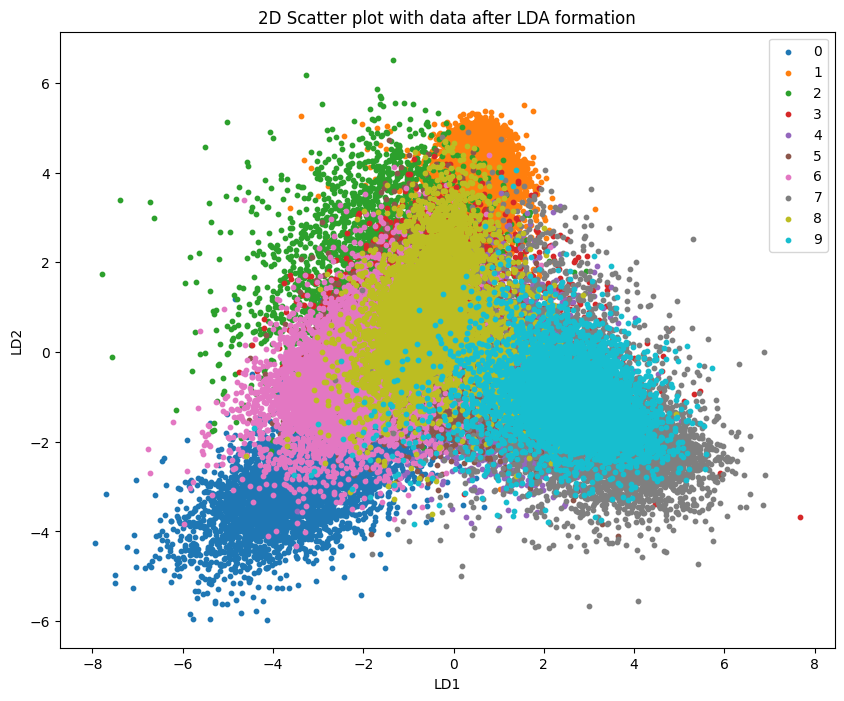

In [325]:
# Initialize LDA
lda = LinearDiscriminantAnalysis(n_components=2)

# Apply LDA to data
x_train_lda = lda.fit_transform(x_train_scale, y_train)

plt.figure(figsize=(10,8))

for num in range(10):
  plt.scatter(x_train_lda[y_train == num, 0], x_train_lda[y_train == num, 1], label=str(num), s=10)

plt.legend()
plt.title("2D Scatter plot with data after LDA formation")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()


Repeat question 4, using the umap library: https://umap-learn.readthedocs.io/en/latest/ (may need to be installed in colab: !pip install umap-learn). Compare the separation of the U-MAP method with that of the LDA.


Yes, there is a big difference between the two methods. Specifically, U-MAP has separated the dataset much better and some classes are clearly much more easily separable. Clases 6, 1, 8, 0, 5, 2 are better seperated rather than with LDA. Now clasters are easier to be found but there are still some failures 4-7-9.

It is very important that class like 4 is visible and in LDA was NOT.

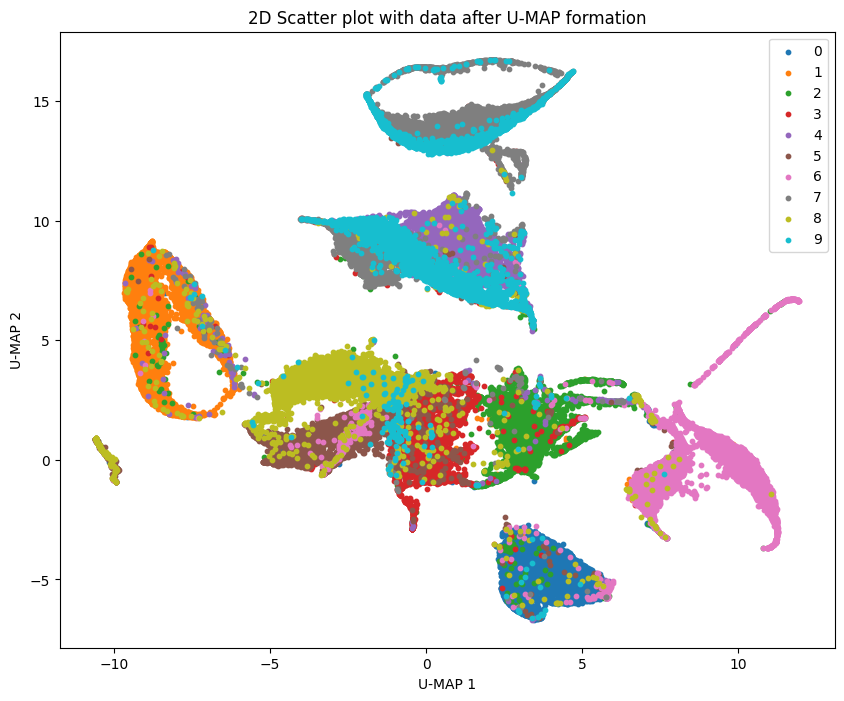

In [331]:
# Initialize U-MAP
u_map = umap.UMAP(n_components=2, random_state=42)

# Apply U-MAP to data
x_train_u_map = u_map.fit_transform(x_train_scale)

plt.figure(figsize=(10,8))

for num in range(10):
  plt.scatter(x_train_u_map[y_train == num, 0], x_train_u_map[y_train == num, 1], label=str(num), s=10)

plt.legend()
plt.title("2D Scatter plot with data after U-MAP formation")
plt.xlabel("U-MAP 1")
plt.ylabel("U-MAP 2")
plt.show()
